In [1]:
# 1. Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import joblib

In [2]:
# 2. Load dataset
DATASET_PATH = 'Career_Path_Dataset_with_Career.csv'
df = pd.read_csv(DATASET_PATH)
df.head()


,Age,Gender,Location,Highest_qualification,Stream,Current_Academic_Level,Grade_CGPA_Percentage,Technical_Skills,Soft_Skills,Languages_Known,Certifications,Fields_of_Interest,Preferred_Work_Style,Work_Type_Interest,Past_Jobs_Internships,Achievements,Skills_Gained,Willing_to_Relocate,Suggested_Career_Path
0,24,Male,Hyderabad,B.Tech,ECE,Student,92.30,JavaScript,"Leadership, Time Management, Communication","English, Hindi",NaN,Data Science,Remote,Technical,Part-time Job,Top Performer,Teamwork,Yes,Data Scientist
1,23,Other,Pune,B.Sc,BBA,Working Professional,99.30,"Data Analysis, Node.js, C++",Leadership,Telugu,"Python, Azure",Software Development,Office,Creative,NaN,Employee of the Month,Data Analysis,No,Frontend Developer
2,23,Male,Hyderabad,12th,Civil,Working Professional,59.15,C++,"Creativity, Teamwork",Hindi,Data Science,AI/ML,Office,Technical,Freelance Project,NaN,Programming,No,Deep Learning Engineer
3,27,Other,Pune,12th,Mechanical,Graduate,71.92,C++,"Creativity, Teamwork, Communication","Hindi, English",Full Stack Development,Marketing,Office,Social,NaN,Top Performer,Teamwork,Yes,Marketing Executive
4,30,Male,Mumbai,MBA,EEE,Working Professional,77.22,"HTML/CSS, C++",Communication,Marathi,"Full Stack Development, Python",Cybersecurity,Remote,Social,NaN,Awarded Best Project,Programming,Yes,Ethical Hacker


In [3]:
# 3. Separate features & target
target_col = 'Suggested_Career_Path'
X = df.drop(columns=[target_col])
y = df[target_col]

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

In [4]:
# 4. Preprocessing
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

In [5]:
# 5. Model
model = RandomForestClassifier(n_estimators=200, random_state=42)

clf = Pipeline([
    ('prep', preprocessor),
    ('model', model)
])

In [6]:
# 6. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [7]:
# 7. Training
clf.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Age', 'Grade_CGPA_Percentage'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Gender...t_qualification', 'Stream',
       'Current_Academic_Level', 'Technical_Skills', 'Soft_Skills',
       'Languages_Known', 'Certifications', 'Fields_of_Interest',
       'Preferred_Work_Style', 'Work_Type_Interest', 'Past_Jobs_Internships',
       'Achievements', 'Skills_Gained', 'Willing_to_Relocate'],
      dtype='object'))])),
                ('model',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

In [8]:
# 8. Evaluation
y_pred = clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)
print(classification_report(y_test, y_pred))

Accuracy: 0.32666666666666666
                              precision    recall  f1-score   support

               AI Researcher       0.29      0.24      0.26       138
           Backend Developer       0.25      0.27      0.26       112
            Business Analyst       0.39      0.35      0.37       141
            Business Manager       0.34      0.41      0.37       147
       Cybersecurity Analyst       0.37      0.38      0.38       143
                Data Analyst       0.37      0.43      0.40       144
              Data Scientist       0.37      0.36      0.36       143
      Deep Learning Engineer       0.38      0.41      0.40       143
Digital Marketing Specialist       0.29      0.22      0.25       141
              Ethical Hacker       0.38      0.30      0.33       138
          Frontend Developer       0.28      0.38      0.32       116
        Full Stack Developer       0.16      0.14      0.15       111
            Graphic Designer       0.28      0.25      0.27

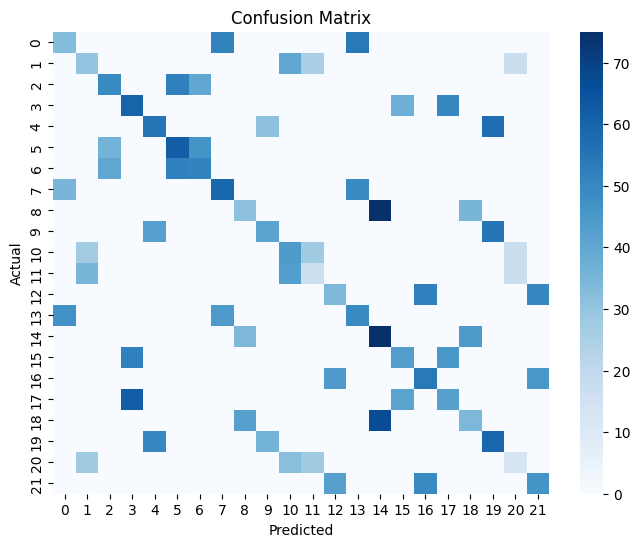

In [9]:
# 9. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False, cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

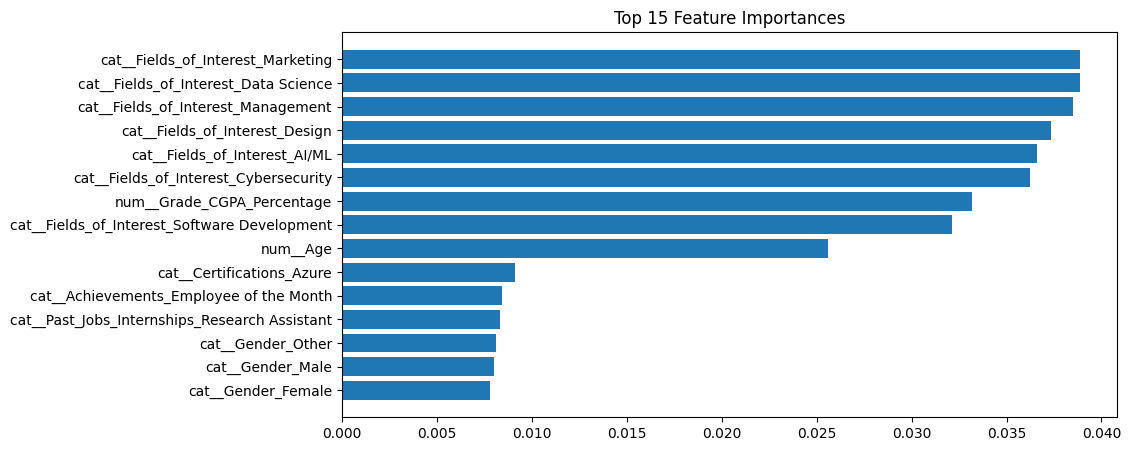

In [10]:
# 10. Feature Importance (Top 15)
feature_names = clf.named_steps['prep'].get_feature_names_out()
importances = clf.named_steps['model'].feature_importances_

fi = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi = fi.sort_values(by='importance', ascending=False).head(15)

plt.figure(figsize=(10,5))
plt.barh(fi['feature'], fi['importance'])
plt.gca().invert_yaxis()
plt.title('Top 15 Feature Importances')
plt.show()

In [11]:
# 11. Save model
joblib.dump(clf, 'career_model.joblib')
print('Model saved')

Model saved
